In [3]:
import torchvision
from torchvision import transforms
import torch
from torchtune.datasets import ConcatDataset 

In [4]:
transformer = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.5),
    transforms.ToTensor()
])

In [5]:
datadir = "/kaggle/input/fruit-recognition/train/train"
data_set = torchvision.datasets.ImageFolder(datadir, transformer)
data_set.classes


['Apple Braeburn',
 'Apple Granny Smith',
 'Apricot',
 'Avocado',
 'Banana',
 'Blueberry',
 'Cactus fruit',
 'Cantaloupe',
 'Cherry',
 'Clementine',
 'Corn',
 'Cucumber Ripe',
 'Grape Blue',
 'Kiwi',
 'Lemon',
 'Limes',
 'Mango',
 'Onion White',
 'Orange',
 'Papaya',
 'Passion Fruit',
 'Peach',
 'Pear',
 'Pepper Green',
 'Pepper Red',
 'Pineapple',
 'Plum',
 'Pomegranate',
 'Potato Red',
 'Raspberry',
 'Strawberry',
 'Tomato',
 'Watermelon']

In [6]:
x, y = data_set[15]

x

tensor([[[0.9922, 0.9961, 1.0000,  ..., 0.9961, 1.0000, 1.0000],
         [0.9961, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
         [1.0000, 0.9961, 0.9961,  ..., 1.0000, 1.0000, 1.0000],
         ...,
         [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000]],

        [[1.0000, 0.9922, 0.9882,  ..., 1.0000, 1.0000, 1.0000],
         [0.9961, 1.0000, 0.9961,  ..., 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000,  ..., 0.9961, 1.0000, 1.0000],
         ...,
         [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000]],

        [[0.9961, 0.9922, 0.9961,  ..., 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.

In [7]:
len(data_set)

16854

In [8]:
from torch.utils.data import random_split

train_dataset, test_dataset = random_split(data_set, [0.8, 0.2])
print(len(test_dataset))
len(train_dataset)


3370


13484

In [9]:
from torch.utils.data import DataLoader


batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

In [10]:
for x, y in train_loader:
    break

y

tensor([17, 16, 10,  9, 26, 29, 18, 25, 27,  2, 24, 17, 22, 13, 10, 30,  2,  7,
        14,  0, 25, 13,  1,  8, 19, 24, 10, 31,  9, 25, 16, 29,  1, 22, 15, 10,
         0,  4, 26, 30,  9, 29,  2, 32,  8,  3, 22, 19, 30, 27, 12,  0, 22, 14,
        31, 18,  6,  4,  9, 26,  3, 23,  2, 28, 18, 12,  4, 31, 26, 27, 12, 20,
         8, 32, 28, 19, 29,  6, 15,  1, 20,  0, 22,  7, 22, 21, 32, 22,  1, 15,
        15, 21, 22,  7, 29,  0, 20, 10, 32,  3, 15, 13,  9, 24, 23, 22,  1,  0,
        31, 15, 26,  8, 13, 11, 25, 30,  7,  9, 21,  2,  6,  2,  4, 17, 20, 12,
         4, 15])

In [11]:
x.shape

torch.Size([128, 3, 64, 64])

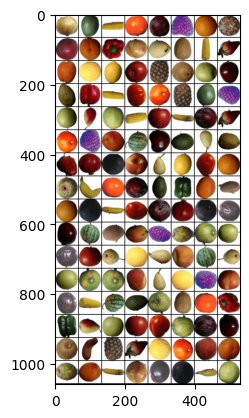

In [12]:
from torchvision.utils import make_grid
import matplotlib.pyplot as plt


grid = make_grid(x).permute(1, 2, 0)

plt.imshow(grid)

#HomeWork2


In [13]:
img, label = train_dataset[0]
img.shape



torch.Size([3, 64, 64])

In [14]:
len(data_set.classes)


33

In [15]:
from torch import nn

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(12288, 500),
    nn.ReLU(),
    nn.Linear(500, 250),
    nn.ReLU(),
    nn.Linear(250, 125),
    nn.ReLU(),
    nn.Linear(125, 75),
    nn.ReLU(),
    nn.Linear(75, 33)
)

In [16]:
device = 'cuda'
model = model.to(device)

In [17]:
# Функція втрат для класифікації
loss_fn = nn.CrossEntropyLoss()

# Оптимізатор (Adam) для оновлення ваг моделі
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

In [18]:
epochs = 10
losses = []
losses_test = []
for epoch in range(epochs):
    losses2 = []
    for img, label in train_loader:
        img, label = img.to(device), label.to(device)
        pred = model(img)
        loss = loss_fn(pred, label)
        losses2.append(loss.item())
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    losses.append(sum(losses2) / len(losses2))

    loss_test = []
    for img, label in test_loader:
        img, label = img.to(device), label.to(device)
        pred = model(img)
        loss = loss_fn(pred, label)
        loss_test.append(loss.item())
    losses_test.append(sum(loss_test) / len(loss_test))
    
    print(losses[-1], losses_test[-1])

2.924200433042814 1.2764825997529206
0.7710988310710439 0.8298770145133689
0.5583835062834451 0.43231724699338275
0.4482862319586412 0.41069713676417313
0.34267894052109626 0.2660749394584585
0.4005619100523445 0.5732220223656407
0.25473791649037936 0.20932301878929138
0.26519094351327643 0.21807082107773534
0.17706559306748634 0.35028360066590486
0.2872623773115986 0.3379817814738662


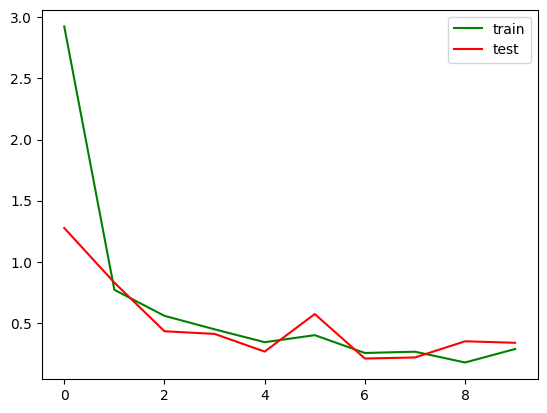

In [19]:
import matplotlib.pyplot as plt

plt.plot(losses, label='train', color='green')
plt.plot(losses_test, label='test', color='red')
plt.legend()

In [20]:
3 * 64 * 64

12288

In [26]:
import numpy as np
from torch import nn
import torch.nn.functional as F


class Model(nn.Module):
     def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,8, 3, padding="same")
        self.conv2 = nn.Conv2d(8, 16, 3, padding="same")
        self.conv3 = nn.Conv2d(16, 32, 3, padding="same")
        self.pooling = nn.MaxPool2d(2,2)
        self.Flatting = nn.Flatten()
        
        self.lin1 = nn.Linear(2048,200)
        self.lin2 = nn.Linear(200, 33)
        
        
    def forward(self, x):
        #3*64*64
        conv1 = self.conv1(x) #8*64*64
        relu1 = F.relu(conv1)
        pool1 = self.pooling(relu1) #8*32*32

        conv2 = self.conv2(pool1)  # 16*32*32
        relu2 = F.relu(conv2)
        pool2 = self.pooling(relu2)  # 16*16*16

        conv3 = self.conv3(pool2)  # 32*16*16
        relu3 = F.relu(conv3)
        pool3 = self.pooling(relu3)  # 32*8*8
        
        flat = self.Flatting(pool3) #2048
        
        lin1 = self.lin1(flat) #200
        relu4 = F.relu(lin1)

        lin2 = self.lin2(relu4) #2
        
        return lin2

model = Model()
device = "cuda"
model = model.to(device)

IndentationError: unindent does not match any outer indentation level (<tokenize>, line 19)

In [ ]:
# Функція втрат для класифікації
loss_fn = nn.CrossEntropyLoss()

# Оптимізатор (Adam) для оновлення ваг моделі
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)